In [227]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score




In [228]:
df=sns.load_dataset('tips')
df.columns = df.columns.str.strip()

In [229]:

df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [230]:
# df=df[['total_bill','tip','size']]

In [231]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

In [232]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [233]:
cat_col=['sex','smoker','day','time']
print(df.columns.tolist())


['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [234]:
print(df.columns)

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [235]:
ct=ColumnTransformer(
    transformers=[
        ('onehot',OneHotEncoder(drop='first'),['sex','smoker','day','time'])
        # ('smoker',OneHotEncoder(drop='first'),['smoker']),
        # ('day',OneHotEncoder(drop='first'),['day']),
        # ('time',OneHotEncoder(drop='first'),['time'])
    ],remainder='passthrough'
)
X_encoded=ct.fit_transform(df)


In [236]:
feature_names=ct.get_feature_names_out()

In [237]:
X_encoded_df=pd.DataFrame(X_encoded,columns=feature_names,index=df.index)

In [238]:
X_encoded_df=X_encoded_df = X_encoded_df.astype(int)

In [239]:
X_encoded_df

,onehot__sex_Male,onehot__smoker_Yes,onehot__day_Sat,onehot__day_Sun,onehot__day_Thur,onehot__time_Lunch,remainder__total_bill,remainder__tip,remainder__size
0,0,0,0,1,0,0,16,1,2
1,1,0,0,1,0,0,10,1,3
2,1,0,0,1,0,0,21,3,3
3,1,0,0,1,0,0,23,3,2
4,0,0,0,1,0,0,24,3,4
...,...,...,...,...,...,...,...,...,...
239,1,0,1,0,0,0,29,5,3
240,0,1,1,0,0,0,27,2,2
241,1,1,1,0,0,0,22,2,2
242,1,0,1,0,0,0,17,1,2


In [240]:
df= pd.concat([df, X_encoded_df], axis=1)

In [241]:
df.drop(['sex','smoker','day','time'],inplace=True,axis=1)

In [242]:
df

,total_bill,tip,size,onehot__sex_Male,onehot__smoker_Yes,onehot__day_Sat,onehot__day_Sun,onehot__day_Thur,onehot__time_Lunch,remainder__total_bill,remainder__tip,remainder__size
0,16.99,1.01,2,0,0,0,1,0,0,16,1,2
1,10.34,1.66,3,1,0,0,1,0,0,10,1,3
2,21.01,3.50,3,1,0,0,1,0,0,21,3,3
3,23.68,3.31,2,1,0,0,1,0,0,23,3,2
4,24.59,3.61,4,0,0,0,1,0,0,24,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,3,1,0,1,0,0,0,29,5,3
240,27.18,2.00,2,0,1,1,0,0,0,27,2,2
241,22.67,2.00,2,1,1,1,0,0,0,22,2,2
242,17.82,1.75,2,1,0,1,0,0,0,17,1,2


In [243]:
df=df[['size','total_bill','tip']]

In [244]:
df.head()

,size,total_bill,tip
0,2,16.99,1.01
1,3,10.34,1.66
2,3,21.01,3.50
3,2,23.68,3.31
4,4,24.59,3.61


In [245]:
X=df[['size','total_bill']]
y=df[['tip']]

In [246]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [247]:
import warnings
warnings.filterwarnings("ignore")


In [248]:
df.describe()

,size,total_bill,tip
count,244.000000,244.000000,244.000000
mean,2.569672,19.785943,2.998279
std,0.951100,8.902412,1.383638
min,1.000000,3.070000,1.000000
25%,2.000000,13.347500,2.000000
50%,2.000000,17.795000,2.900000
75%,3.000000,24.127500,3.562500
max,6.000000,50.810000,10.000000


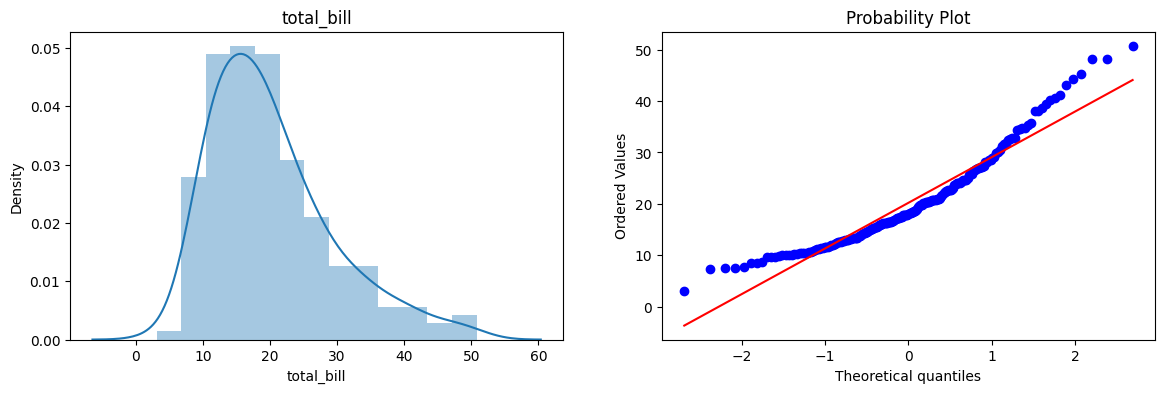

In [249]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['total_bill'])
plt.title('total_bill')
plt.subplot(122)
stats.probplot(X_train['total_bill'],dist='norm',plot=plt)
plt.show()

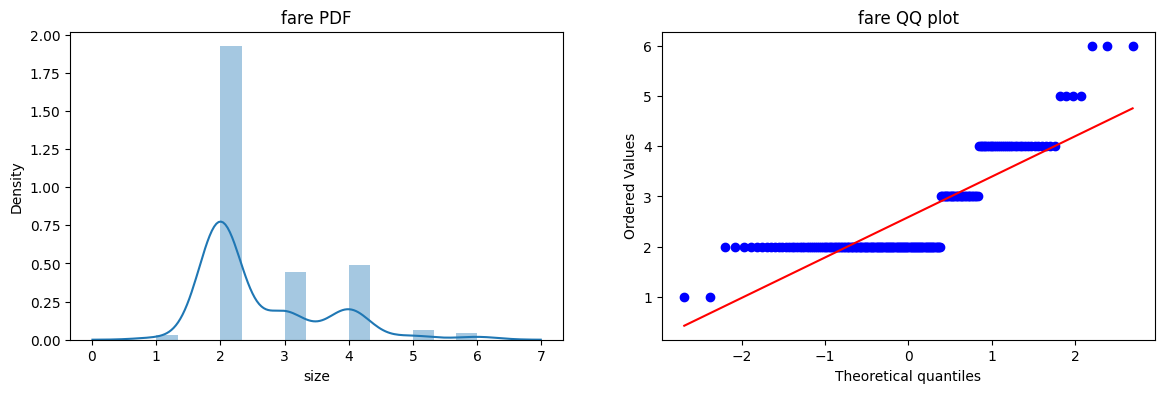

In [250]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['size'],kde=True)
plt.title('fare PDF')
plt.subplot(122)
stats.probplot(X_train['size'],dist='norm',plot=plt)
plt.title("fare QQ plot")
plt.show()

In [287]:
from sklearn. preprocessing import PowerTransformer
pt=PowerTransformer(method='box-cox')
X_train_transformed=pt.fit_transform(X_train+0.000001)
X_test_transformed=pt.transform(X_test+0.000001)
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,size,-0.858206
1,total_bill,0.101864


In [288]:
lr=LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred2=lr.predict(X_test_transformed)
r2_score(y_test,y_pred2)

0.5696501108473877

In [255]:
clf = LinearRegression()
clf2 = DecisionTreeRegressor(max_depth=4,
    min_samples_leaf=10,
    random_state=42)
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [256]:
y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

In [257]:
print("LinearRegression : ",r2_score(y_test,y_pred))
print("DecisionTreeRegressor : ",r2_score(y_test,y_pred1))

LinearRegression :  0.5931538868815657
DecisionTreeRegressor :  0.5161313177372571


In [258]:
trf=FunctionTransformer(func=np.log1p)

In [263]:
X_train_transform=trf.fit_transform(X_train)
X_test_transform=trf.transform(X_test)

In [267]:
clf.fit(X_train_transform,y_train)
clf2.fit(X_train_transform,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [272]:
y_pred=clf.predict(X_test_transform)
y_pred1=clf2.predict(X_test_transform)

In [273]:
print("LinearRegression : ",r2_score(y_test,y_pred))
print("DecisionTreeRegressor : ",r2_score(y_test,y_pred1))

LinearRegression :  0.5752013361701347
DecisionTreeRegressor :  0.5161313177372571


In [275]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
ridge = Ridge(alpha=0.5)
random=RandomForestRegressor()
trf=FunctionTransformer(func=np.log1p)

In [277]:
ridge.fit(X_train_transform,y_train)
random.fit(X_train_transform,y_train)
y_pred=ridge.predict(X_test_transform)
y_pred1=random.predict(X_test_transform)

In [279]:
print("Ridge : ",r2_score(y_test,y_pred))
print("Random : ",r2_score(y_test,y_pred1))

Ridge :  0.5725257180642913
Random :  0.46839908474010905


# Now we can say that Ridge and random is worse than Linear or Decision Tree Classifier
# LinearRegression  >  Ridge  >  DecisionTree  >  RandomForest


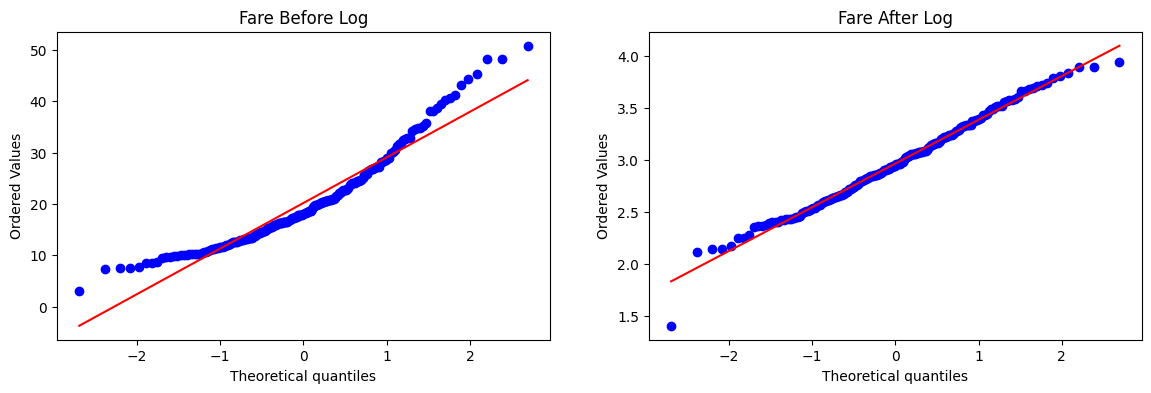

In [281]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['total_bill'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats. probplot(X_train_transform['total_bill'], dist="norm", plot=plt)
plt.title('Fare After Log' )

plt.show()

In [285]:
X_transformed2=trf.fit_transform(X) 
ridge = Ridge(alpha=0.5)
random=RandomForestRegressor()
print("ridge",np.mean(r2_score(ridge,X_transformed2,y,scoring='accuracy',cv=10)))
print("random",np.mean(cr2_score(random,X_transformed2,y,scoring='accuracy',cv=10)))

TypeError: too many positional arguments